# Google Play Store Data Analysis Project


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as s

In [2]:
df = pd.read_csv('googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
df.shape

(10841, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [5]:
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [6]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [7]:
# stats
print(np.max(df['Rating']))
print(np.min(df['Rating']))

19.0
1.0


In [8]:
df.isnull().sum()       # these are the null values per each column

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [9]:
df.isnull().sum().sum()   # They are 1487 null values in Data

np.int64(1487)

In [10]:
df.duplicated().sum()           # we have 483 duplicates

np.int64(483)

In [11]:
duplicates = df['App'][df['App'].duplicated()]
print(duplicates.value_counts())                    # Duplicate Applications

App
ROBLOX                                               8
CBS Sports App - Scores, News, Stats & Watch Live    7
ESPN                                                 6
Duolingo: Learn Languages Free                       6
Candy Crush Saga                                     6
                                                    ..
Xero Accounting Software                             1
HipChat - Chat Built for Teams                       1
Insightly CRM                                        1
FreshBooks Classic                                   1
Zenefits                                             1
Name: count, Length: 798, dtype: int64


In [12]:
df[(df['Rating'] >= 0)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10834,FR Calculator,FAMILY,4.0,7,2.6M,500+,Free,0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [13]:
df[(df['Rating'] > 5.0)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [102]:
# Observations
# 1. There are 483 duplicate applications
# 2. There are 1341 null values in Rating column
# 3. Rating column as one outlier
# There are 1487 null values in dataset

# Clean the data

In [14]:
df_clean = df.copy()

In [15]:
df_clean.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [16]:
# Remove duplicate rows
df_clean.drop_duplicates(inplace=True)   # Dropping Duplicates..

In [17]:
df_clean.duplicated().sum()

np.int64(0)

In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10358 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10358 non-null  object 
 1   Category        10358 non-null  object 
 2   Rating          8893 non-null   float64
 3   Reviews         10358 non-null  object 
 4   Size            10358 non-null  object 
 5   Installs        10358 non-null  object 
 6   Type            10357 non-null  object 
 7   Price           10358 non-null  object 
 8   Content Rating  10357 non-null  object 
 9   Genres          10358 non-null  object 
 10  Last Updated    10358 non-null  object 
 11  Current Ver     10350 non-null  object 
 12  Android Ver     10355 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [19]:
# Task 3: Fix the invalid Rating row
df_clean.loc[10472, 'Rating'] = np.nan

In [20]:
print(np.max(df_clean['Rating']))

5.0


In [21]:
df_clean[(df_clean['Rating'] > 5.0)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [22]:
# dropping missing Rating
df_clean.dropna(subset=['Rating'], inplace=True)
df_clean['Rating'].isnull().sum()

np.int64(0)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
# Convert Reviews to numeric

In [25]:
df_clean['Reviews'] = df_clean['Rating'].astype('int')

In [24]:
# Convert Reviews to numeric
df_clean['Reviews'] = df_clean['Reviews'].str.replace('M','',regex=True)
df_clean['Reviews']=df_clean['Reviews'].str.replace('.','',regex=True)

In [26]:
df_clean['Rating']

0        4.1
1        3.9
2        4.7
3        4.5
4        4.3
        ... 
10834    4.0
10836    4.5
10837    5.0
10839    4.5
10840    4.5
Name: Rating, Length: 8892, dtype: float64

In [27]:
df_clean['Reviews'].dtype

dtype('int64')

In [ ]:
# Convert Installs to numeric
df_clean['Installs'] = df_clean['Installs'].str.replace('+', '')
df_clean['Installs'] = df_clean['Installs'].str.replace(',', '')
df_clean['Installs'] = df_clean['Installs'].replace('Free',0)


In [33]:
df_clean['Installs'] = df_clean['Installs'].astype('int')

#df['Installs'].dtypes
df_clean['Installs'].dtypes

dtype('int64')

In [36]:
df_clean['Content Rating'] = df_clean['Content Rating'].fillna('Unknown')
df_clean['Type'] = df_clean['Type'].fillna('Unknown')
df_clean['Current Ver'] = df_clean['Current Ver'].fillna('Unknown Version')
df_clean['Android Ver'] = df_clean['Android Ver'].fillna('Unknown Version')


In [40]:
# Quick check
df_clean.shape

(8892, 13)

In [ ]:
df_clean.describe()

In [41]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8892 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8892 non-null   object 
 1   Category        8892 non-null   object 
 2   Rating          8892 non-null   float64
 3   Reviews         8892 non-null   int64  
 4   Size            8892 non-null   object 
 5   Installs        8892 non-null   int64  
 6   Type            8892 non-null   object 
 7   Price           8892 non-null   object 
 8   Content Rating  8892 non-null   object 
 9   Genres          8892 non-null   object 
 10  Last Updated    8892 non-null   object 
 11  Current Ver     8892 non-null   object 
 12  Android Ver     8892 non-null   object 
dtypes: float64(1), int64(2), object(10)
memory usage: 972.6+ KB


In [43]:
df_clean.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [44]:
df_clean[(df_clean['Rating'] > 5.0)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [ ]:
# Observations
# 1. Removed duplicated Values 
# 2. Replaced null values
# 3. Converted Reviews,installs to  Numeric data type
# 4. Removed inconsistent data having rating above 5

In [108]:
d = pd.read_csv('Cleaned_data.csv')
d

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,4,19M,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,3,14M,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,4,8.7M,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,4,25M,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,4,2.8M,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8887,FR Calculator,FAMILY,4.0,4,2.6M,500,Free,0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
8888,Sya9a Maroc - FR,FAMILY,4.5,4,53M,5000,Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
8889,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,5,3.6M,100,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
8890,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,4,Varies with device,1000,Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [ ]:
df_clean.to_csv('Cleaned_data.csv',index=False)

In [109]:
d.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [110]:
d.describe()

,Rating,Reviews,Installs
count,8892.000000,8892.000000,8.892000e+03
mean,4.187877,3.774067,1.648965e+07
std,0.522377,0.568856,8.637600e+07
min,1.000000,1.000000,1.000000e+00
25%,4.000000,4.000000,1.000000e+04
50%,4.300000,4.000000,5.000000e+05
75%,4.500000,4.000000,5.000000e+06
max,5.000000,5.000000,1.000000e+09


# EDA 

In [6]:
# unq_categories
unq_categories = d['Category'].value_counts()                

In [ ]:
# Average rating per category
avg_rating = d.groupby(['Category'])['Rating'].agg('mean')

In [ ]:
# Sort to find the highest
top_rating = avg_rating.sort_values(ascending=False)

In [9]:
# Show top 5 and bottom 5 categories
top_rating.head()

Category
EVENTS                 4.435556
EDUCATION              4.375969
ART_AND_DESIGN         4.358065
BOOKS_AND_REFERENCE    4.347458
PERSONALIZATION        4.333871
Name: Rating, dtype: float64

In [10]:
top_rating.tail()

Category
TRAVEL_AND_LOCAL       4.094146
VIDEO_PLAYERS          4.063750
MAPS_AND_NAVIGATION    4.051613
TOOLS                  4.047411
DATING                 3.971698
Name: Rating, dtype: float64

In [ ]:
# Count apps per category (optional but useful)
d.groupby('Category')['App'].agg('count')

In [ ]:
Create a horizontal bar chart showing the top 10 (or top 5) categories by average rating. 


Use seaborn barplot with 
Category on y-axis and
Rating on x-axis.

In [ ]:
#a_r = d.groupby('Category')['Rating'].agg('mean')
#a_r = a_r.sort_values(ascending=False).head(10)

In [ ]:
a_r.sort_values(ascending=True).head(5) 

Category
DATING                 3.971698
TOOLS                  4.047411
MAPS_AND_NAVIGATION    4.051613
VIDEO_PLAYERS          4.063750
TRAVEL_AND_LOCAL       4.094146
Name: Rating, dtype: float64

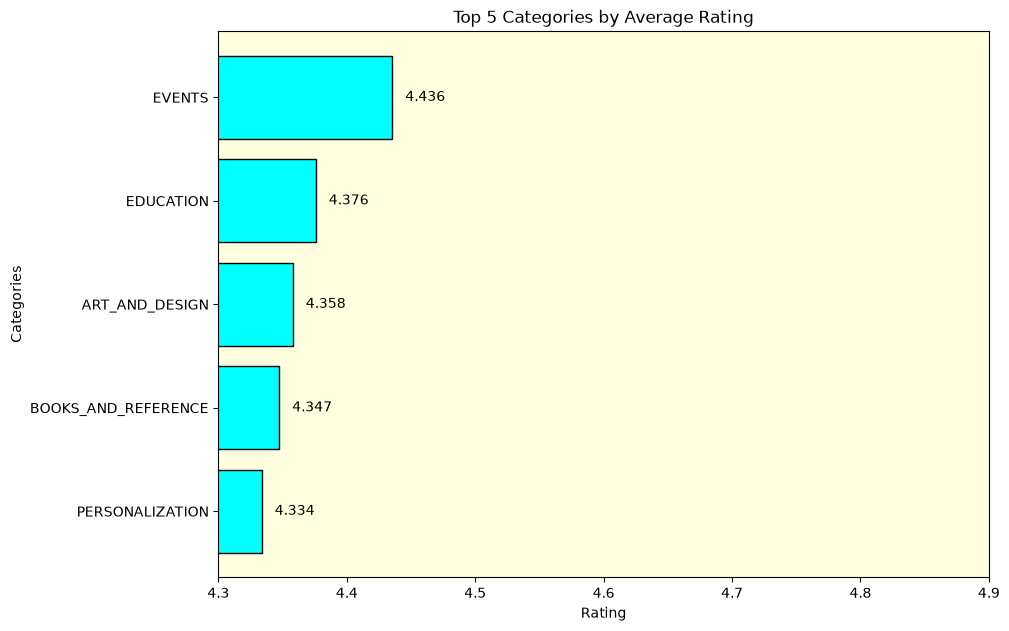

In [ ]:
plt.figure(figsize=(10, 6))
sorted_data = a_r_1.sort_values(ascending=True)
bars = plt.barh(sorted_data.index, sorted_data.values,color='cyan',edgecolor='black')
plt.xlim(4.3, 4.9)  # zoom in to see differences

# Add value labels
for bar, val in zip(bars, sorted_data.values):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center')


plt.tight_layout()
plt.title('Top 5 Categories by Average Rating')
plt.xlabel('Rating')
plt.ylabel('Categories')
plt.gca().set_facecolor('lightyellow')
plt.show()

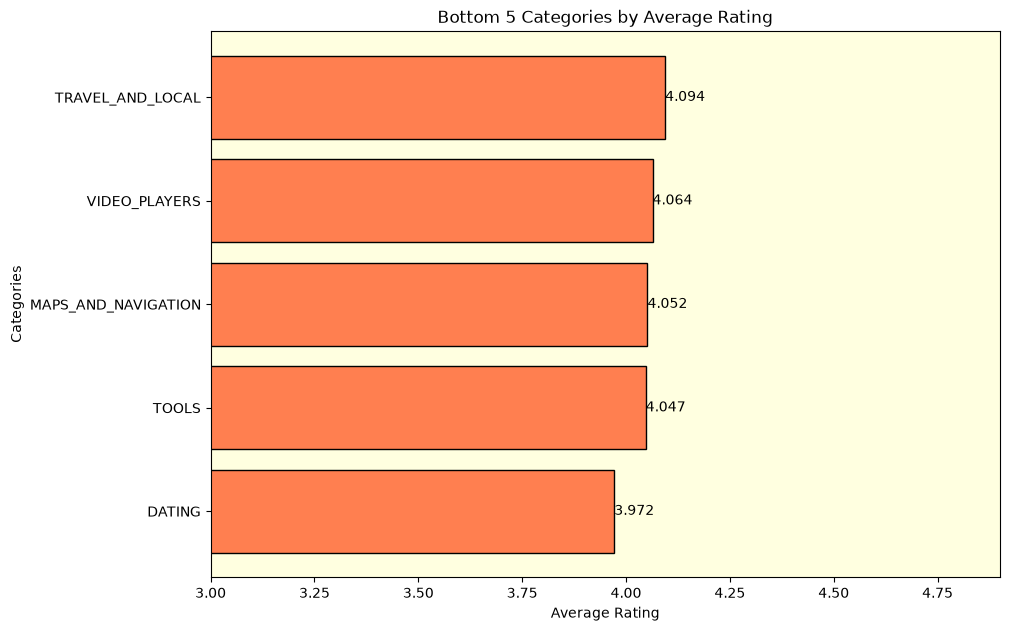

In [106]:
# Get bottom 5 categories by rating
bottom_5 = d.groupby('Category')['Rating'].mean().sort_values().head(5)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
plt.xlim(3.0, 4.9)  # zoom in to see differences
x = plt.barh(bottom_5.index, bottom_5.values, color='coral',edgecolor='black')
plt.bar_label(x,fmt='%.3f')

plt.tight_layout()
plt.title('Bottom 5 Categories by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Categories')
plt.gca().set_facecolor('lightyellow')
plt.show()



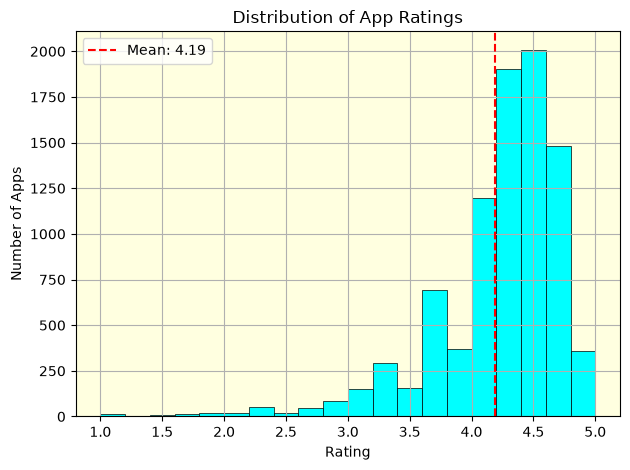

In [ ]:
#  Rating Distribution (Histogram)

plt.hist(d['Rating'],bins=20,color='cyan',edgecolor='black',linewidth=0.5)
plt.axvline(d['Rating'].mean(), color='red', linestyle='--', label=f"Mean: {d['Rating'].mean():.2f}")
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.grid()
plt.gca().set_facecolor('lightyellow')
plt.legend()
plt.show()


In [142]:
apps = d['Type'].value_counts()
apps

Type
Free    8279
Paid     613
Name: count, dtype: int64

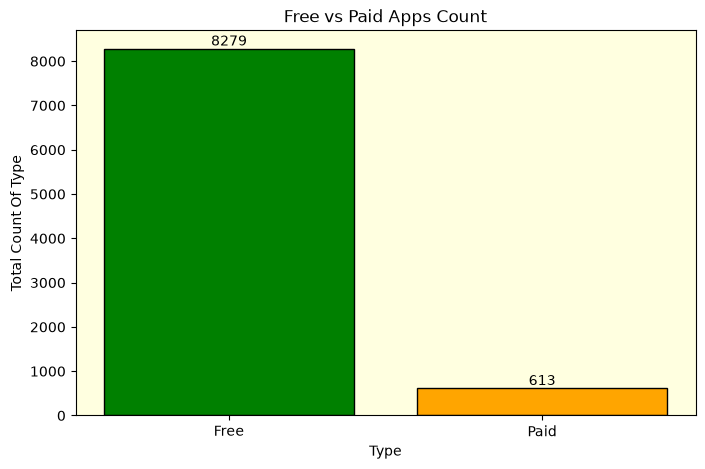

In [146]:
# Free vs Paid Apps Count
plt.figure(figsize=(8,5))
z = plt.bar(apps.index,apps.values,edgecolor='black',color=['green','orange'])  
plt.bar_label(z)
plt.xlabel('Type')
plt.ylabel('Total Count Of Type')
plt.title('Free vs Paid Apps Count')
plt.gca().set_facecolor('lightyellow')
plt.show()



In [148]:
top_installs = d.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

In [149]:
top_installs

Category
GAME                  31543862717
COMMUNICATION         24152241530
SOCIAL                12513841475
PRODUCTIVITY          12463070180
TOOLS                 11450724500
FAMILY                10041130590
PHOTOGRAPHY            9721243130
TRAVEL_AND_LOCAL       6361859300
VIDEO_PLAYERS          6221897200
NEWS_AND_MAGAZINES     5393110650
Name: Installs, dtype: int64

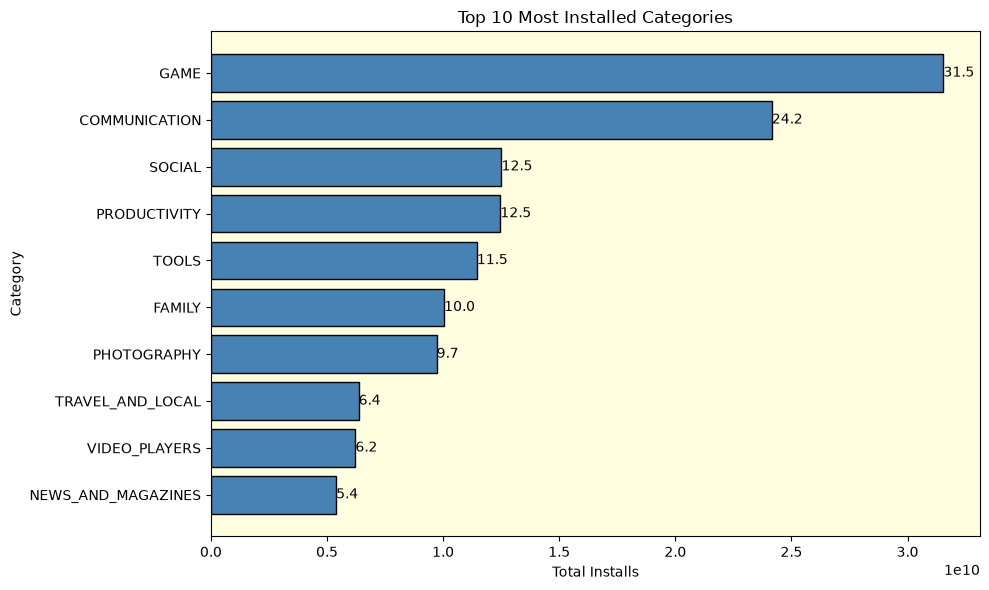

In [170]:
sorted_1 = top_installs.sort_values(ascending=True)
plt.figure(figsize=(10,6))
g = plt.barh(sorted_1.index,sorted_1.values,color='steelblue', edgecolor='black')
plt.bar_label(g, labels=[f'{v/1e9:.1f}' for v in sorted_1.values])
plt.title('Top 10 Most Installed Categories')
plt.xlabel('Total Installs')
plt.ylabel('Category')
plt.tight_layout()
plt.gca().set_facecolor('lightyellow')
plt.show()

# App Count per Category
- The dataset contains 33 unique categories. 
- After checking the count of apps per category, most categories have a sufficient number of apps (30+) to make their average rating reliable. 
- The EVENTS category, despite having the highest average rating (4.43), has 45 apps — which is a reasonable sample size, so the result is trustworthy.
- 93% of apps on the Play Store are free (8279 free vs 613 paid), showing the dominance of the freemium model.
- GAME and COMMUNICATION are the most installed categories with 31.5B and 24.2B installs respectively, despite not being the highest rated.

In [98]:
d.groupby('Category')['App'].agg('count')

Category
ART_AND_DESIGN           62
AUTO_AND_VEHICLES        73
BEAUTY                   42
BOOKS_AND_REFERENCE     177
BUSINESS                270
COMICS                   58
COMMUNICATION           307
DATING                  159
EDUCATION               129
ENTERTAINMENT           111
EVENTS                   45
FAMILY                 1718
FINANCE                 317
FOOD_AND_DRINK          106
GAME                   1074
HEALTH_AND_FITNESS      262
HOUSE_AND_HOME           68
LIBRARIES_AND_DEMO       65
LIFESTYLE               305
MAPS_AND_NAVIGATION     124
MEDICAL                 302
NEWS_AND_MAGAZINES      214
PARENTING                50
PERSONALIZATION         310
PHOTOGRAPHY             304
PRODUCTIVITY            334
SHOPPING                202
SOCIAL                  244
SPORTS                  286
TOOLS                   734
TRAVEL_AND_LOCAL        205
VIDEO_PLAYERS           160
WEATHER                  75
Name: App, dtype: int64

In [105]:
# All categories have sufficient app counts (min 42), no filtering needed
app_counts = d.groupby('Category')['App'].agg('count')
print(f"Minimum app count: {app_counts.min()}")
print(f"Category with least apps: {app_counts.idxmin()}")

Minimum app count: 42
Category with least apps: BEAUTY


No categories were filtered out. Every category in this dataset has at least 42 apps, which is a sufficient sample size to make the average ratings statistically meaningful.

# Conclusion

- The top 5 highest rated categories are EVENTS, EDUCATION, ART_AND_DESIGN, BOOKS_AND_REFERENCE, and PERSONALIZATION — all averaging above 4.33.
- The bottom 5 lowest rated categories are DATING, TOOLS, MAPS_AND_NAVIGATION, VIDEO_PLAYERS, and TRAVEL_AND_LOCAL — all averaging below 4.10.
- DATING has the lowest rating likely because dating apps tend to receive polarizing reviews — users either love or hate their experience.
- EDUCATION and ART_AND_DESIGN rank high because users who download these apps are intentional and satisfied with niche, purpose-driven tools.
- Since all categories have 42+ apps, none of the results are statistically unreliable.

